### 修改使之支持 Overlap

In [2]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np

# 输入参数
# 1. 拓扑
k = 2  # OCS 数量
B = 400 * 1024 * 1024 / 8  # 带宽，400Gbps，转换为字节/秒
T_reconf = 2  # 重配置时间，1ms，转换为秒
# 2. CC
p = 8  # 计算节点数量
m = 400 * 1024 * 1024  # 总消息大小，800MB，转换为字节
s = int(np.log2(p))  # HD 算法的步骤数

# Havling-Doubling 算法，每个步骤的消息大小 m_i，从步骤 1 开始
num_steps = 2 * s
m_i = {}
for i in range(1, num_steps + 1):
    if i <= s:
        m_i[i] = m / (2 ** (i))
    else:
        m_i[i] = m_i[2 * s + 1 - i]

# 定义配置编号，使得步骤 i 和步骤 (2s - i + 1) 具有相同的 OCS 配置
configurations = {}
for i in range(1, num_steps + 1):
    configurations[i] = min(i, 2 * s - i + 1)

# 创建模型
model = gp.Model("Halving_Doubling_Optimization")

# 定义变量
d = model.addVars(range(1, num_steps + 1), range(k), vtype=GRB.CONTINUOUS, name="d")  # 消息大小变量
t_start = model.addVars(range(1, num_steps + 1), range(k), vtype=GRB.CONTINUOUS, name="t_start")
t_end = model.addVars(range(1, num_steps + 1), range(k), vtype=GRB.CONTINUOUS, name="t_end")
u = model.addVars(range(1, num_steps + 1), range(k), vtype=GRB.BINARY, name="u")
r = model.addVars(range(1, num_steps + 1), range(k), vtype=GRB.BINARY, name="r")
t_reconf_start = model.addVars(range(1, num_steps + 1), range(k), vtype=GRB.CONTINUOUS, name="t_reconf_start")
t_reconf_end = model.addVars(range(1, num_steps + 1), range(k), vtype=GRB.CONTINUOUS, name="t_reconf_end")
t_step_end = model.addVars(range(1, num_steps + 1), vtype=GRB.CONTINUOUS, name="t_step_end")
CCT = model.addVar(vtype=GRB.CONTINUOUS, name="CCT")

# 大常数 M，用于约束
M = m  # 一个足够大的常数 # TODO: FIXME

# 配置编号的最大差值，用于配置比较
M_config = max(configurations.values())  # 配置编号的最大值

# 定义 delta_{i,j}，表示配置是否变化
delta = model.addVars(range(1, num_steps + 1), range(k), vtype=GRB.BINARY, name="delta")
# 定义 same_config_{i,j}，表示配置是否相同
same_config = model.addVars(range(1, num_steps + 1), range(k), vtype=GRB.BINARY, name="same_config")
# 定义 t_prev_end_{i,j}，表示 OCS j 在步骤 i 前的最后活动结束时间
t_prev_end = model.addVars(range(1, num_steps + 1), range(k), vtype=GRB.CONTINUOUS, name="t_prev_end")

# 设置目标函数
model.setObjective(CCT, GRB.MINIMIZE)

# 约束条件

# (1) 消息大小约束
for i in range(1, num_steps + 1):
    model.addConstr(gp.quicksum(d[i, j] for j in range(k)) == m_i[i], name=f"msg_size_step_{i}")

# (2) 带宽限制约束
for i in range(1, num_steps + 1):
    for j in range(k):
        model.addConstr(t_end[i, j] - t_start[i, j] == d[i, j] / B, name=f"bandwidth_step_{i}_ocs_{j}")

# (3) 使用指示变量约束
for i in range(1, num_steps + 1):
    for j in range(k):
        model.addConstr(d[i, j] <= u[i, j] * M, name=f"use_indicator_step_{i}_ocs_{j}")
        model.addConstr(d[i, j] >= 0, name=f"d_nonnegative_step_{i}_ocs_{j}")
        model.addConstr(u[i, j] <= 1, name=f"u_binary_upper_step_{i}_ocs_{j}")
        model.addConstr(u[i, j] >= 0, name=f"u_binary_lower_step_{i}_ocs_{j}")

# (4) 重配置时间约束
for i in range(1, num_steps + 1):
    for j in range(k):
        model.addConstr(t_reconf_end[i, j] - t_reconf_start[i, j] == r[i, j] * T_reconf, name=f"reconf_time_step_{i}_ocs_{j}")
        model.addConstr(r[i, j] <= 1, name=f"r_binary_upper_step_{i}_ocs_{j}")
        model.addConstr(r[i, j] >= 0, name=f"r_binary_lower_step_{i}_ocs_{j}")

# (5) 传输与重配置的依赖关系
for i in range(1, num_steps + 1):
    for j in range(k):
        model.addConstr(t_start[i, j] >= t_reconf_end[i, j], name=f"trans_after_reconf_step_{i}_ocs_{j}")

# (6) OCS 活动时间不重叠约束
for j in range(k):
    for i in range(1, num_steps + 1):
        if i == 1:
            model.addConstr(t_prev_end[i, j] == 0, name=f"t_prev_end_step_{i}_ocs_{j}")
        else:
            model.addConstr(t_prev_end[i, j] >= t_end[i - 1, j] * u[i - 1, j], name=f"t_prev_end_trans_step_{i}_ocs_{j}")
            model.addConstr(t_prev_end[i, j] >= t_reconf_end[i - 1, j] * r[i - 1, j], name=f"t_prev_end_reconf_step_{i}_ocs_{j}") # DEBUG: 
        # 重配置开始时间不早于上一次活动结束时间
        model.addConstr(t_reconf_start[i, j] >= t_prev_end[i, j], name=f"reconf_after_prev_end_step_{i}_ocs_{j}")

# (7) 配置变化指示变量 delta_{i,j}
for i in range(1, num_steps + 1):
    for j in range(k):
        # 如果 u_{i,j} == 1，则需要判断配置是否变化
        # 计算配置差值的绝对值
        if i == 1:
            # 初始步骤，没有上一次配置，假设需要重配置
            model.addConstr(delta[i, j] >= u[i, j], name=f"delta_initial_step_{i}_ocs_{j}")
        else:
            # 定义 same_config_{i,j}
            # 配置相同，则 same_config_{i,j} = 1
            # 配置不同，则 same_config_{i,j} = 0
            config_diff = abs(configurations[i] - configurations[i - 1])
            if config_diff == 0:
                model.addConstr(same_config[i, j] == 1, name=f"same_config_step_{i}_ocs_{j}")
            else:
                model.addConstr(same_config[i, j] == 0, name=f"same_config_step_{i}_ocs_{j}")
            # delta_{i,j} >= u_{i,j} * (1 - same_config_{i,j})
            model.addConstr(delta[i, j] >= u[i, j] - same_config[i, j], name=f"delta_def_step_{i}_ocs_{j}")

# (8) 重配置需求约束
for i in range(1, num_steps + 1):
    for j in range(k):
        model.addConstr(r[i, j] >= delta[i, j], name=f"reconf_need_step_{i}_ocs_{j}")

# (9) 步骤完成时间定义
for i in range(1, num_steps + 1):
    for j in range(k):
        model.addConstr(t_step_end[i] >= t_end[i, j] * u[i, j], name=f"step_end_step_{i}_ocs_{j}")

# (10) 步骤依赖性约束
for i in range(2, num_steps + 1):
    for j in range(k):
        model.addConstr(t_start[i, j] >= t_step_end[i - 1], name=f"trans_after_prev_step_end_step_{i}_ocs_{j}")

# (11) 通信完成时间定义
for i in range(1, num_steps + 1):
    model.addConstr(CCT >= t_step_end[i], name=f"CCT_def_step_{i}")

# 运行优化
model.optimize()

# 提取结果并显示
if model.status == GRB.OPTIMAL:
    print(f"Optimal CCT: {CCT.X * 1000:.2f} ms")
    schedule = []
    for i in range(1, num_steps + 1):
        for j in range(k):
            d_ij = d[i, j].X
            t_start_ij = t_start[i, j].X
            t_end_ij = t_end[i, j].X
            u_ij = u[i, j].X
            r_ij = r[i, j].X
            t_reconf_start_ij = t_reconf_start[i, j].X
            t_reconf_end_ij = t_reconf_end[i, j].X
            schedule.append({
                'step': i,
                'ocs': j + 1,
                'd': d_ij,
                't_start': t_start_ij,
                't_end': t_end_ij,
                'reconf': r_ij,
                't_reconf_start': t_reconf_start_ij,
                't_reconf_end': t_reconf_end_ij,
                'used': u_ij
            })
    # 按开始时间排序
    schedule.sort(key=lambda s: s['t_start'])

    # 输出调度结果
    for s in schedule:
        print(f"Step {s['step']}, OCS {s['ocs']}, Used: {s['used']}, Data: {s['d']}, "
              f"TransTime: {s['t_start']:.6f}-{s['t_end']:.6f}, "
              f"Reconf: {s['reconf']}, ReconfTime: {s['t_reconf_start']:.6f}-{s['t_reconf_end']:.6f}")
else:
    print("No optimal solution found.")

Set parameter Username


GurobiError: License expired 2025-11-21

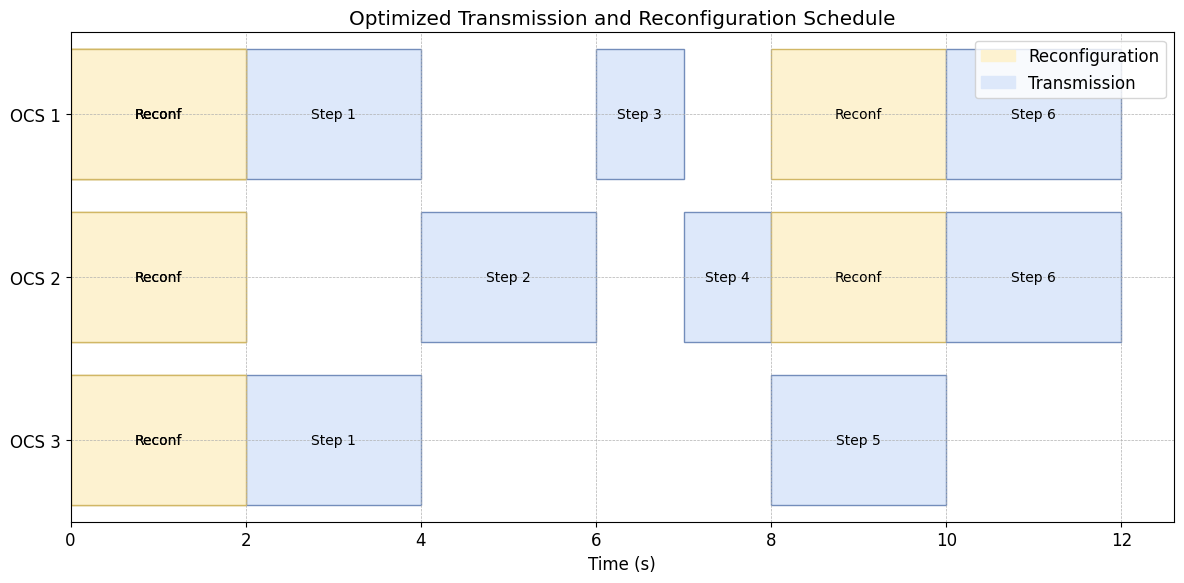

In [229]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_schedule(schedule, num_ocs, T_reconf, save_as_pdf=False, filename='schedule.pdf'):
    # 函数实现# 定义颜色和样式
    colors = {
        'transmission': '#dde8fa',       # 蓝色
        'transmission_edgecolor': '#738dbb',
        'reconfiguration': '#fdf2d0',    # 橙色
        'reconfiguration_edgecolor': '#d1b765',
        'idle': '#DDDDDD',               # 浅灰色（未使用）
        'edgecolor': 'black'
    }
    # 创建绘图对象
    fig, ax = plt.subplots(figsize=(12, 6))

    # 设置字体和字号
    plt.rcParams.update({'font.size': 12})

    for ocs in range(1, num_ocs + 1):
        y = num_ocs - ocs  # OCS 编号从上到下排列
        ocs_schedule = [s for s in schedule if s['ocs'] == ocs]
        for s in ocs_schedule:
            # 绘制重配置阶段
            if s['reconf'] > 0.5:
                ax.barh(
                    y,
                    s['t_reconf_end'] - s['t_reconf_start'],
                    left=s['t_reconf_start'],
                    height=0.8,
                    color=colors['reconfiguration'],
                    edgecolor=colors['reconfiguration_edgecolor']
                )
                ax.text(
                    s['t_reconf_start'] + (s['t_reconf_end'] - s['t_reconf_start']) / 2,
                    y,
                    "Reconf",
                    ha='center',
                    va='center',
                    color='black',
                    fontsize=10,
                    fontweight='normal'
                )
            # 绘制传输阶段
            if s['used'] > 0.5 and s['d'] > 0:
                ax.barh(
                    y,
                    s['t_end'] - s['t_start'],
                    left=s['t_start'],
                    height=0.8,
                    color=colors['transmission'],
                    edgecolor=colors['transmission_edgecolor']
                )
                ax.text(
                    s['t_start'] + (s['t_end'] - s['t_start']) / 2,
                    y,
                    f"Step {s['step']}",
                    ha='center',
                    va='center',
                    color='black',
                    fontsize=10,
                    fontweight='normal'
                )
    
    # 设置 y 轴刻度和标签
    ax.set_yticks(range(num_ocs))
    ax.set_yticklabels([f"OCS {i}" for i in range(num_ocs, 0, -1)])
    ax.set_ylim(-0.5, num_ocs - 0.5)  # 调整 y 轴范围

    # 设置 x 轴标签、标题和网格
    ax.set_xlabel("Time (s)")
    ax.set_title("Optimized Transmission and Reconfiguration Schedule")
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    
    # 添加图例
    reconf_patch = mpatches.Patch(color=colors['reconfiguration'], label='Reconfiguration')
    trans_patch = mpatches.Patch(color=colors['transmission'], label='Transmission')
    ax.legend(handles=[reconf_patch, trans_patch], loc='upper right')
    
    # 调整布局
    plt.tight_layout()

    # 保存为 PDF（如果需要）
    if save_as_pdf:
        plt.savefig(filename, format='pdf', bbox_inches='tight')

    # 显示图表
    plt.show()

# 假设已经得到了 schedule 列表
plot_schedule(schedule, num_ocs=k, T_reconf=T_reconf, save_as_pdf=True, filename='optimized_schedule.pdf')

In [223]:
schedule

[{'step': 1,
  'ocs': 1,
  'd': 69905066.66666667,
  't_start': 2,
  't_end': 3.3333333333333335,
  'reconf': 1,
  't_reconf_start': 0,
  't_reconf_end': 2,
  'used': 1},
 {'step': 1,
  'ocs': 2,
  'd': 69905066.66666667,
  't_start': 2,
  't_end': 3.3333333333333335,
  'reconf': 1,
  't_reconf_start': 0,
  't_reconf_end': 2,
  'used': 1},
 {'step': 1,
  'ocs': 3,
  'd': 69905066.66666667,
  't_start': 2,
  't_end': 3.3333333333333335,
  'reconf': 1,
  't_reconf_start': 0,
  't_reconf_end': 2,
  'used': 1},
 {'step': 2,
  'ocs': 1,
  'd': 34952533.333333336,
  't_start': 5.333333333333334,
  't_end': 6.000000000000001,
  'reconf': 1,
  't_reconf_start': 3.3333333333333335,
  't_reconf_end': 5.333333333333334,
  'used': 1},
 {'step': 2,
  'ocs': 2,
  'd': 34952533.333333336,
  't_start': 5.333333333333334,
  't_end': 6.000000000000001,
  'reconf': 1,
  't_reconf_start': 3.3333333333333335,
  't_reconf_end': 5.333333333333334,
  'used': 1},
 {'step': 2,
  'ocs': 3,
  'd': 34952533.333333

Baseline CCT: 16666.67 ms


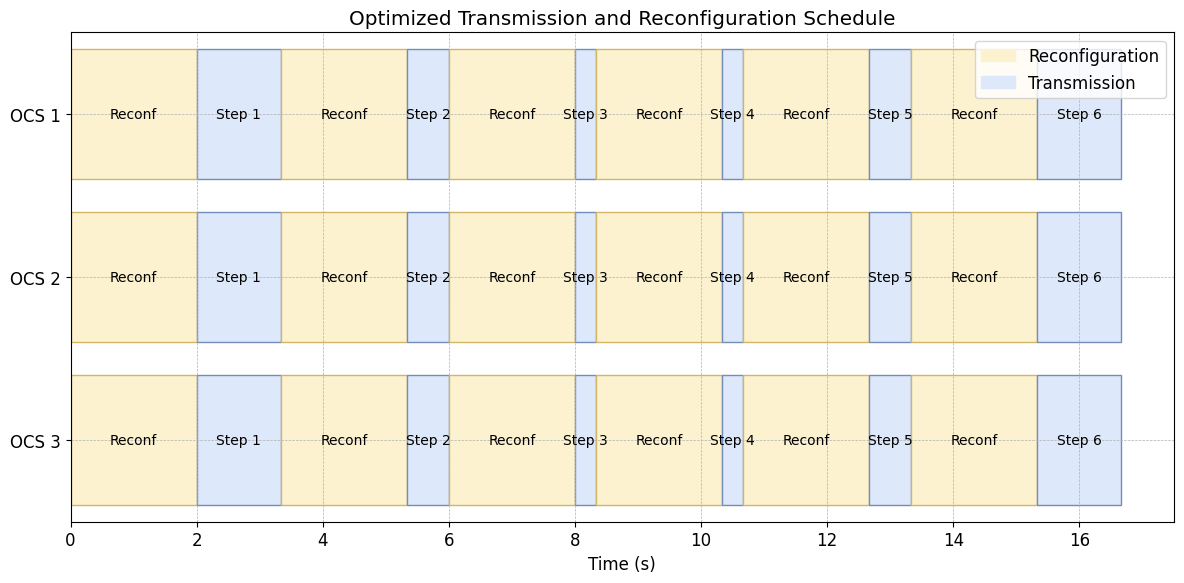

In [222]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 输入参数
p = 8  # 计算节点数量
m = 400 * 1024 * 1024  # 总消息大小，800MB，转换为字节
k = 3  # OCS 数量
B = 400 * 1024 * 1024 / 8  # 带宽，400Gbps，转换为字节/秒
T_reconf = 2  # 重配置时间，1ms，转换为秒
s = int(np.log2(p))  # HD 算法的步骤数

# 总步骤数
num_steps = 2 * s

# 计算每个步骤的消息大小 m_i，从步骤 1 开始
m_i = {}
for i in range(1, num_steps + 1):
    if i <= s:
        m_i[i] = m / (2 ** (i))
    else:
        m_i[i] = m_i[2 * s + 1 - i] # DEBUG: (m / p) * (2 ** (i - s))

# # 定义配置编号，使得步骤 i 和步骤 (2s - i + 1) 具有相同的配置
configurations = {}
for i in range(1, num_steps + 1):
    configurations[i] = min(i, 2 * s - i + 1)

# 计算每个步骤每个 OCS 需要传输的数据量
d = {}
for i in range(1, num_steps + 1):
    for j in range(k):
        d[i, j] = m_i[i] / k  # 均匀分配

# 初始化变量
t_start = {}  # 传输开始时间
t_end = {}    # 传输结束时间
t_reconf_start = {}  # 重配置开始时间
t_reconf_end = {}    # 重配置结束时间
t_step_end = {}      # 步骤完成时间
u = {}  # 使用指示变量
r = {}  # 重配置指示变量

# 初始化 OCS 上一次活动结束时间
t_prev_end = [0] * k  # 列表，长度为 k，初始为 0

# 构建 schedule 列表
schedule = []

# 遍历每个步骤，计算时间
for i in range(1, num_steps + 1):
    # 计算传输时间
    trans_time = (m_i[i] / k) / B  # 每个 OCS 的传输时间
    for j in range(k):
        # 重配置指示变量，Baseline 方案中每个步骤都需要重配置
        r[i, j] = 1
        # 使用指示变量
        u[i, j] = 1 if d[i, j] > 0 else 0

        # 重配置开始和结束时间
        t_reconf_start[i, j] = t_prev_end[j]
        t_reconf_end[i, j] = t_reconf_start[i, j] + T_reconf

        # 传输开始和结束时间
        t_start[i, j] = t_reconf_end[i, j]
        t_end[i, j] = t_start[i, j] + trans_time

        # 更新 OCS 上一次活动结束时间
        t_prev_end[j] = t_end[i, j]

        # 将当前活动添加到 schedule 列表
        schedule.append({
            'step': i,
            'ocs': j + 1,
            'd': d[i, j],
            't_start': t_start[i, j],
            't_end': t_end[i, j],
            'reconf': r[i, j],
            't_reconf_start': t_reconf_start[i, j],
            't_reconf_end': t_reconf_end[i, j],
            'used': u[i, j]
        })

    # 步骤完成时间为所有 OCS 中传输结束时间的最大值
    t_step_end[i] = max(t_end[i, j] for j in range(k))

# 通信完成时间为最后一个步骤的完成时间
CCT = t_step_end[num_steps]

print(f"Baseline CCT: {CCT * 1000:.2f} ms")

# 按开始时间排序 schedule
schedule.sort(key=lambda s: s['t_start'])

# 输出每个步骤的时间信息
for s in schedule:
    print(f"Step {s['step']}, OCS {s['ocs']}, Used: {s['used']}, Data: {s['d'] / (1024 * 1024):.2f} MB, "
          f"TransTime: {s['t_start']:.6f}-{s['t_end']:.6f}, "
          f"Reconf: {s['reconf']}, ReconfTime: {s['t_reconf_start']:.6f}-{s['t_reconf_end']:.6f}")

# 调用 plot_schedule 函数，绘制并保存调度图
plot_schedule(schedule, num_ocs=k, T_reconf=T_reconf, save_as_pdf=True, filename='baseline_schedule.pdf')

Baseline CCT: 17000.000000 ms
Step 1, OCS 1, Used: 1, Data: 100.00 MB, TransTime: 2.000000-4.000000 s, Reconf: 1, ReconfTime: 0.000000-2.000000 s
Step 1, OCS 2, Used: 1, Data: 100.00 MB, TransTime: 2.000000-4.000000 s, Reconf: 1, ReconfTime: 0.000000-2.000000 s
Step 2, OCS 1, Used: 1, Data: 50.00 MB, TransTime: 6.000000-7.000000 s, Reconf: 1, ReconfTime: 4.000000-6.000000 s
Step 2, OCS 2, Used: 1, Data: 50.00 MB, TransTime: 6.000000-7.000000 s, Reconf: 1, ReconfTime: 4.000000-6.000000 s
Step 3, OCS 1, Used: 1, Data: 25.00 MB, TransTime: 9.000000-9.500000 s, Reconf: 1, ReconfTime: 7.000000-9.000000 s
Step 3, OCS 2, Used: 1, Data: 25.00 MB, TransTime: 9.000000-9.500000 s, Reconf: 1, ReconfTime: 7.000000-9.000000 s
Step 4, OCS 1, Used: 1, Data: 25.00 MB, TransTime: 9.500000-10.000000 s, Reconf: 0, ReconfTime: 9.500000-9.500000 s
Step 4, OCS 2, Used: 1, Data: 25.00 MB, TransTime: 9.500000-10.000000 s, Reconf: 0, ReconfTime: 9.500000-9.500000 s
Step 5, OCS 1, Used: 1, Data: 50.00 MB, TransT

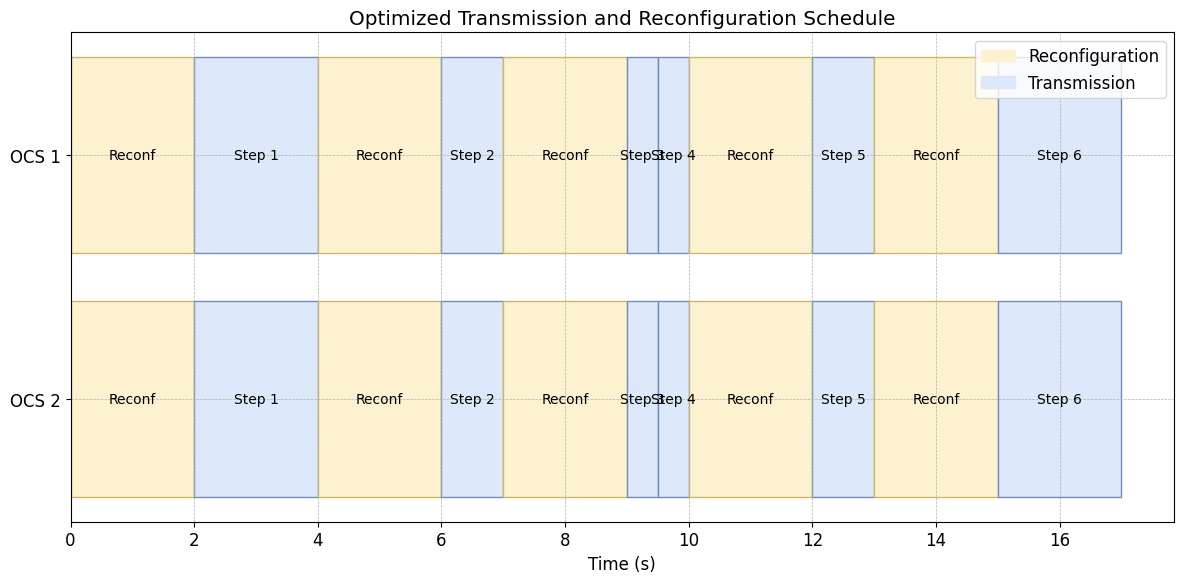

In [233]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


# 输入参数
p = 8  # 计算节点数量
m = 400 * 1024 * 1024  # 总消息大小，800MB，转换为字节
k = 2  # OCS 数量
B = 400 * 1024 * 1024 / 8  # 带宽，400Gbps，转换为字节/秒
T_reconf = 2  # 重配置时间，1ms，转换为秒
s = int(np.log2(p))  # HD 算法的步骤数

# 总步骤数
num_steps = 2 * s

# 计算每个步骤的消息大小 m_i，从步骤 1 开始
m_i = {}
for i in range(1, num_steps + 1):
    if i <= s:
        m_i[i] = m / (2 ** (i))
    else:
        m_i[i] = m_i[2 * s + 1 - i] # DEBUG: (m / p) * (2 ** (i - s))

# 定义配置编号，使得步骤 i 和步骤 (2s - i + 1) 具有相同的配置
configurations = {}
for i in range(1, num_steps + 1):
    configurations[i] = min(i, 2 * s - i + 1)

# 创建 schedule 列表
schedule = []

# 初始化 OCS 的上一次配置和可用时间
last_config = [None] * k  # 列表，长度为 k，存储每个 OCS 的最后配置编号
available_time = [0.0] * k  # 列表，长度为 k，存储每个 OCS 的可用时间

# 遍历每个步骤，计算时间
for i in range(1, num_steps + 1):
    for j in range(k):
        current_config = configurations[i]
        # 检查是否需要重配置
        if last_config[j] != current_config:
            # 需要重配置
            reconf_needed = 1
            t_reconf_start = available_time[j]
            t_reconf_end = t_reconf_start + T_reconf
        else:
            # 不需要重配置
            reconf_needed = 0
            t_reconf_start = available_time[j]
            t_reconf_end = available_time[j]  # 无需重配置

        # 传输开始时间
        t_trans_start = t_reconf_end
        # 传输结束时间
        trans_time = (m_i[i] / k) / B
        t_trans_end = t_trans_start + trans_time

        # 更新 OCS 的可用时间
        available_time[j] = t_trans_end

        # 更新最后配置
        if reconf_needed:
            last_config[j] = current_config

        # 标记是否被使用
        used = 1 if m_i[i] > 0 else 0

        # 将当前活动添加到 schedule 列表
        schedule.append({
            'step': i,
            'ocs': j + 1,
            'd': m_i[i] / k,
            't_start': t_trans_start,
            't_end': t_trans_end,
            'reconf': reconf_needed,
            't_reconf_start': t_reconf_start,
            't_reconf_end': t_reconf_end,
            'used': used
        })

# 计算步骤完成时间和通信完成时间
t_step_end = {}
for i in range(1, num_steps + 1):
    # 获取所有 OCS 在步骤 i 的传输结束时间
    step_trans_end_times = [s['t_end'] for s in schedule if s['step'] == i and s['used'] == 1]
    if step_trans_end_times:
        t_step_end[i] = max(step_trans_end_times)
    else:
        t_step_end[i] = 0.0

# 通信完成时间为最后一个步骤的完成时间
CCT = t_step_end[num_steps]

print(f"Baseline CCT: {CCT * 1000:.6f} ms")

# 按开始时间排序 schedule
schedule.sort(key=lambda s: s['t_start'])

# 输出每个步骤的时间信息
for s in schedule:
    data_MB = s['d'] / (1024 * 1024)  # 转换为 MB
    print(f"Step {s['step']}, OCS {s['ocs']}, Used: {s['used']}, Data: {data_MB:.2f} MB, "
          f"TransTime: {s['t_start']:.6f}-{s['t_end']:.6f} s, "
          f"Reconf: {s['reconf']}, ReconfTime: {s['t_reconf_start']:.6f}-{s['t_reconf_end']:.6f} s")

# 调用 plot_schedule 函数，绘制并保存调度图
plot_schedule(schedule, k, T_reconf, save_as_pdf=True, filename='baseline_schedule.pdf')